# 🚆 Global Rail Transit: Infrastructure, Progression & Geographic Reach
### INFSCI 2415 — Information Visualization — Final Project

## Cell 1 — Install & Import

In [10]:
import sys
!{sys.executable} -m pip install wbgapi cartopy geopandas scipy --quiet

import warnings; warnings.filterwarnings('ignore')
import sys, math
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import networkx as nx
import wbgapi as wb
from functools import reduce
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats as sp_stats

def fp(msg):
    sys.stdout.write('\r' + str(msg))
    sys.stdout.flush()

print('Ready ✓')

Ready ✓



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\gavin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Cell 2 — Pull World Bank Data (one-pass loop, Week 3)

In [11]:
INDICATORS = {
    'IS.RRS.TOTL.KM': 'rail_km',
    'SP.POP.TOTL':    'population',
    'AG.SRF.TOTL.K2': 'area_km2',
    'EN.URB.LCTY':    'urban_pop',
    'SP.POP.DPND':    'dependency'
}
REGION_MAP = {
    'EAS':'East Asia & Pacific', 'ECS':'Europe & Central Asia',
    'LCN':'Latin America',       'MEA':'Middle East & N. Africa',
    'NAC':'North America',       'SAS':'South Asia',
    'SSF':'Sub-Saharan Africa'
}
RCOLS = {
    'East Asia & Pacific':    '#FF8C00',
    'Europe & Central Asia':  '#00CFFF',
    'Latin America':          '#7FFF00',
    'Middle East & N. Africa':'#FF69B4',
    'North America':          '#FF3300',
    'South Asia':             '#DA70D6',
    'Sub-Saharan Africa':     '#FFD700',
    'Other':                  '#888888'
}

print('Fetching World Bank indicators...')
dfs = []
for i, (code, name) in enumerate(INDICATORS.items()):
    fp(f'  Pass {i+1}/{len(INDICATORS)} — {name}...')
    raw = wb.data.DataFrame(code, time=range(1990, 2023), labels=True)
    df  = raw.reset_index()
    iso_col   = next(c for c in df.columns if str(c).lower() == 'economy')
    label_col = next((c for c in df.columns
                      if c != iso_col and str(c).lower() == 'economy'), None)
    year_cols = [c for c in df.columns
                 if c not in {iso_col, label_col}
                 and str(c).lstrip('YRyr').isdigit()]
    id_vars = [iso_col] + ([label_col] if label_col else [])
    long = df.melt(id_vars=id_vars, value_vars=year_cols, var_name='yr', value_name=name)
    long['year'] = long['yr'].astype(str).str.extract(r'(\d{4})').astype(int)
    long = long.rename(columns={iso_col: 'iso3'})
    long['country'] = long[label_col] if label_col else long['iso3']
    dfs.append(long[['iso3','country','year',name]])
    fp(f'  Pass {i+1}/{len(INDICATORS)} — {name} ✓  ({len(long):,} rows)')
    print()

wb_df = reduce(lambda a,b: pd.merge(a,b,on=['iso3','country','year'],how='outer'), dfs)
wb_df['pop_density']     = wb_df['population'] / wb_df['area_km2']
wb_df['rail_density']    = wb_df['rail_km']    / wb_df['area_km2'] * 1000
wb_df['rail_per_capita'] = wb_df['rail_km']    / wb_df['population'] * 1e6
wb_df['urban_pct']       = wb_df['urban_pop']  / wb_df['population'] * 100

# ── Latest snapshot per country ───────────────────────────────────────────────
wb_latest = (
    wb_df.dropna(subset=['rail_km','population'])
         .sort_values('year', ascending=False)
         .groupby('iso3').first().reset_index()
)

# ── Region labels: robust multi-strategy approach ────────────────────────────
# Strategy 1: try wbgapi economy DataFrame
region_ser = None
try:
    eco  = wb.economy.DataFrame().reset_index()
    ecol = next(c for c in eco.columns if str(c).lower()=='economy')
    eco  = eco.rename(columns={ecol:'iso3'})
    # wbgapi 'region' col may contain codes ('EAS') or full names — handle both
    def map_region(val):
        if pd.isna(val): return 'Other'
        v = str(val).strip()
        if v in REGION_MAP: return REGION_MAP[v]          # code -> name
        if v in REGION_MAP.values(): return v              # already a name
        # partial match
        for code, name in REGION_MAP.items():
            if code in v or name[:8] in v: return name
        return 'Other'
    eco['region'] = eco['region'].apply(map_region)
    region_ser = eco.set_index('iso3')['region']
    n_mapped = (region_ser != 'Other').sum()
    print(f'  Region lookup: {n_mapped} countries mapped via wbgapi')
except Exception as e:
    print(f'  wbgapi region lookup failed: {e}')

# Strategy 2: hardcoded ISO3 → region fallback (covers ~90 major countries)
REGION_FALLBACK = {
    # North America
    'USA':'North America','CAN':'North America','MEX':'Latin America',
    # Latin America
    'BRA':'Latin America','ARG':'Latin America','COL':'Latin America',
    'CHL':'Latin America','PER':'Latin America','VEN':'Latin America',
    'BOL':'Latin America','PRY':'Latin America','URY':'Latin America',
    'ECU':'Latin America','GTM':'Latin America','CUB':'Latin America',
    # Europe & Central Asia
    'DEU':'Europe & Central Asia','FRA':'Europe & Central Asia',
    'GBR':'Europe & Central Asia','ITA':'Europe & Central Asia',
    'ESP':'Europe & Central Asia','POL':'Europe & Central Asia',
    'UKR':'Europe & Central Asia','ROU':'Europe & Central Asia',
    'NLD':'Europe & Central Asia','BEL':'Europe & Central Asia',
    'CHE':'Europe & Central Asia','AUT':'Europe & Central Asia',
    'SWE':'Europe & Central Asia','NOR':'Europe & Central Asia',
    'FIN':'Europe & Central Asia','DNK':'Europe & Central Asia',
    'PRT':'Europe & Central Asia','CZE':'Europe & Central Asia',
    'HUN':'Europe & Central Asia','SVK':'Europe & Central Asia',
    'BGR':'Europe & Central Asia','HRV':'Europe & Central Asia',
    'SRB':'Europe & Central Asia','GRC':'Europe & Central Asia',
    'RUS':'Europe & Central Asia','KAZ':'Europe & Central Asia',
    'UZB':'Europe & Central Asia','TKM':'Europe & Central Asia',
    'TUR':'Europe & Central Asia','LTU':'Europe & Central Asia',
    'LVA':'Europe & Central Asia','EST':'Europe & Central Asia',
    'BLR':'Europe & Central Asia','MDA':'Europe & Central Asia',
    'GEO':'Europe & Central Asia','ARM':'Europe & Central Asia',
    'AZE':'Europe & Central Asia','KGZ':'Europe & Central Asia',
    'TJK':'Europe & Central Asia','MKD':'Europe & Central Asia',
    'ALB':'Europe & Central Asia','BIH':'Europe & Central Asia',
    # East Asia & Pacific
    'CHN':'East Asia & Pacific','JPN':'East Asia & Pacific',
    'KOR':'East Asia & Pacific','TWN':'East Asia & Pacific',
    'AUS':'East Asia & Pacific','NZL':'East Asia & Pacific',
    'IDN':'East Asia & Pacific','THA':'East Asia & Pacific',
    'VNM':'East Asia & Pacific','MYS':'East Asia & Pacific',
    'PHL':'East Asia & Pacific','MMR':'East Asia & Pacific',
    'KHM':'East Asia & Pacific','LAO':'East Asia & Pacific',
    'SGP':'East Asia & Pacific','MNG':'East Asia & Pacific',
    'PRK':'East Asia & Pacific','HKG':'East Asia & Pacific',
    # South Asia
    'IND':'South Asia','PAK':'South Asia','BGD':'South Asia',
    'LKA':'South Asia','NPL':'South Asia','AFG':'South Asia',
    # Middle East & N. Africa
    'SAU':'Middle East & N. Africa','IRN':'Middle East & N. Africa',
    'IRQ':'Middle East & N. Africa','EGY':'Middle East & N. Africa',
    'MAR':'Middle East & N. Africa','DZA':'Middle East & N. Africa',
    'TUN':'Middle East & N. Africa','LBY':'Middle East & N. Africa',
    'SYR':'Middle East & N. Africa','JOR':'Middle East & N. Africa',
    'ISR':'Middle East & N. Africa','YEM':'Middle East & N. Africa',
    'ARE':'Middle East & N. Africa','QAT':'Middle East & N. Africa',
    'KWT':'Middle East & N. Africa','OMN':'Middle East & N. Africa',
    # Sub-Saharan Africa
    'NGA':'Sub-Saharan Africa','ETH':'Sub-Saharan Africa',
    'ZAF':'Sub-Saharan Africa','KEN':'Sub-Saharan Africa',
    'GHA':'Sub-Saharan Africa','TZA':'Sub-Saharan Africa',
    'MOZ':'Sub-Saharan Africa','ZMB':'Sub-Saharan Africa',
    'ZWE':'Sub-Saharan Africa','AGO':'Sub-Saharan Africa',
    'CMR':'Sub-Saharan Africa','CIV':'Sub-Saharan Africa',
    'SEN':'Sub-Saharan Africa','MDG':'Sub-Saharan Africa',
    'COD':'Sub-Saharan Africa','COG':'Sub-Saharan Africa',
    'SDN':'Sub-Saharan Africa','SSD':'Sub-Saharan Africa',
    'MLI':'Sub-Saharan Africa','BFA':'Sub-Saharan Africa',
    'UGA':'Sub-Saharan Africa','RWA':'Sub-Saharan Africa',
    'BWA':'Sub-Saharan Africa','NAM':'Sub-Saharan Africa',
}

def get_region(iso3):
    if region_ser is not None:
        r = region_ser.get(iso3, 'Other')
        if r != 'Other': return r
    return REGION_FALLBACK.get(str(iso3), 'Other')

wb_latest['region'] = wb_latest['iso3'].apply(get_region)
wb_df['region']     = wb_df['iso3'].apply(get_region)

n_mapped = (wb_latest['region'] != 'Other').sum()
print(f'  Final: {n_mapped}/{len(wb_latest)} countries have named regions')
print(wb_latest['region'].value_counts().to_string())

# ── Rail change 1990 → latest: built DIRECTLY into wb_latest ─────────────────
# For each country, find earliest year with data and latest year with data
has_rail = wb_df.dropna(subset=['rail_km'])[['iso3','country','year','rail_km']]

first_yr = (has_rail.sort_values('year')
                    .groupby('iso3')
                    .first()
                    .rename(columns={'rail_km':'rail_first','year':'year_first'}))
last_yr  = (has_rail.sort_values('year')
                    .groupby('iso3')
                    .last()
                    .rename(columns={'rail_km':'rail_last','year':'year_last'}))

change_df = first_yr[['rail_first','year_first']].join(last_yr[['rail_last','year_last']])
change_df = change_df.dropna()
# Only include countries with at least 10 years of data span
change_df = change_df[change_df['year_last'] - change_df['year_first'] >= 10]
change_df['change_km']  = change_df['rail_last']  - change_df['rail_first']
change_df['change_pct'] = change_df['change_km'] / change_df['rail_first'] * 100
change_df = change_df.reset_index()   # iso3 becomes a column

# Merge country name and region into change_df
change_df = change_df.merge(
    wb_latest[['iso3','country','region','rail_km']].drop_duplicates('iso3'),
    on='iso3', how='left'
)
change_df['region']  = change_df['region'].fillna('Other')
change_df['country'] = change_df['country'].fillna(change_df['iso3'])

print(f'\n✓ World Bank complete')
print(f'  Countries latest: {len(wb_latest)}')
print(f'  Change data:      {len(change_df)} countries with ≥10yr span')
print(f'  Growers:          {(change_df["change_km"]>0).sum()}')
print(f'  Decliners:        {(change_df["change_km"]<0).sum()}')
change_df.nlargest(5,'change_km')[['country','change_km','change_pct']]

Fetching World Bank indicators...
  Pass 1/5 — rail_km ✓  (8,778 rows)
  Pass 2/5 — population ✓  (8,778 rows)
  Pass 3/5 — area_km2 ✓  (8,778 rows)
  Pass 4/5 — urban_pop ✓  (8,778 rows)
  Pass 5/5 — dependency ✓  (8,778 rows)
  wbgapi region lookup failed: 
  Final: 102/116 countries have named regions
region
Europe & Central Asia      42
Sub-Saharan Africa         20
East Asia & Pacific        14
Other                      14
Latin America              10
Middle East & N. Africa    10
South Asia                  4
North America               2

✓ World Bank complete
  Countries latest: 116
  Change data:      91 countries with ≥10yr span
  Growers:          40
  Decliners:        48


,country,change_km,change_pct
15,CHN,55151.00,100.979566
1,ARG,14716.00,467.174603
79,TKM,5527.00,256.711565
39,IND,5442.73,8.686132
41,IRN,4123.00,77.325581


## Cell 3 — Load Natural Earth Geometry

In [12]:
world = gpd.read_file(
    shpreader.natural_earth(resolution='110m', category='cultural', name='admin_0_countries')
)[['ADM0_A3','NAME','geometry']].rename(columns={'ADM0_A3':'iso3','NAME':'country_name'})

rail_lines = gpd.read_file(
    shpreader.natural_earth(resolution='10m', category='cultural', name='railroads')
)

world_merged = world.merge(wb_latest, on='iso3', how='left')

print(f'Country polygons:  {len(world)}')
print(f'Railroad segments: {len(rail_lines):,}')
print(f'Countries w/ data: {world_merged.rail_km.notna().sum()}')

Country polygons:  177
Railroad segments: 25,413
Countries w/ data: 115


## Cell 4 — MAIN FIGURE (3 panels)
**A:** Choropleth + rail lines  |  **B:** Density vs pop scatter  |  **C:** Growth/decline bar

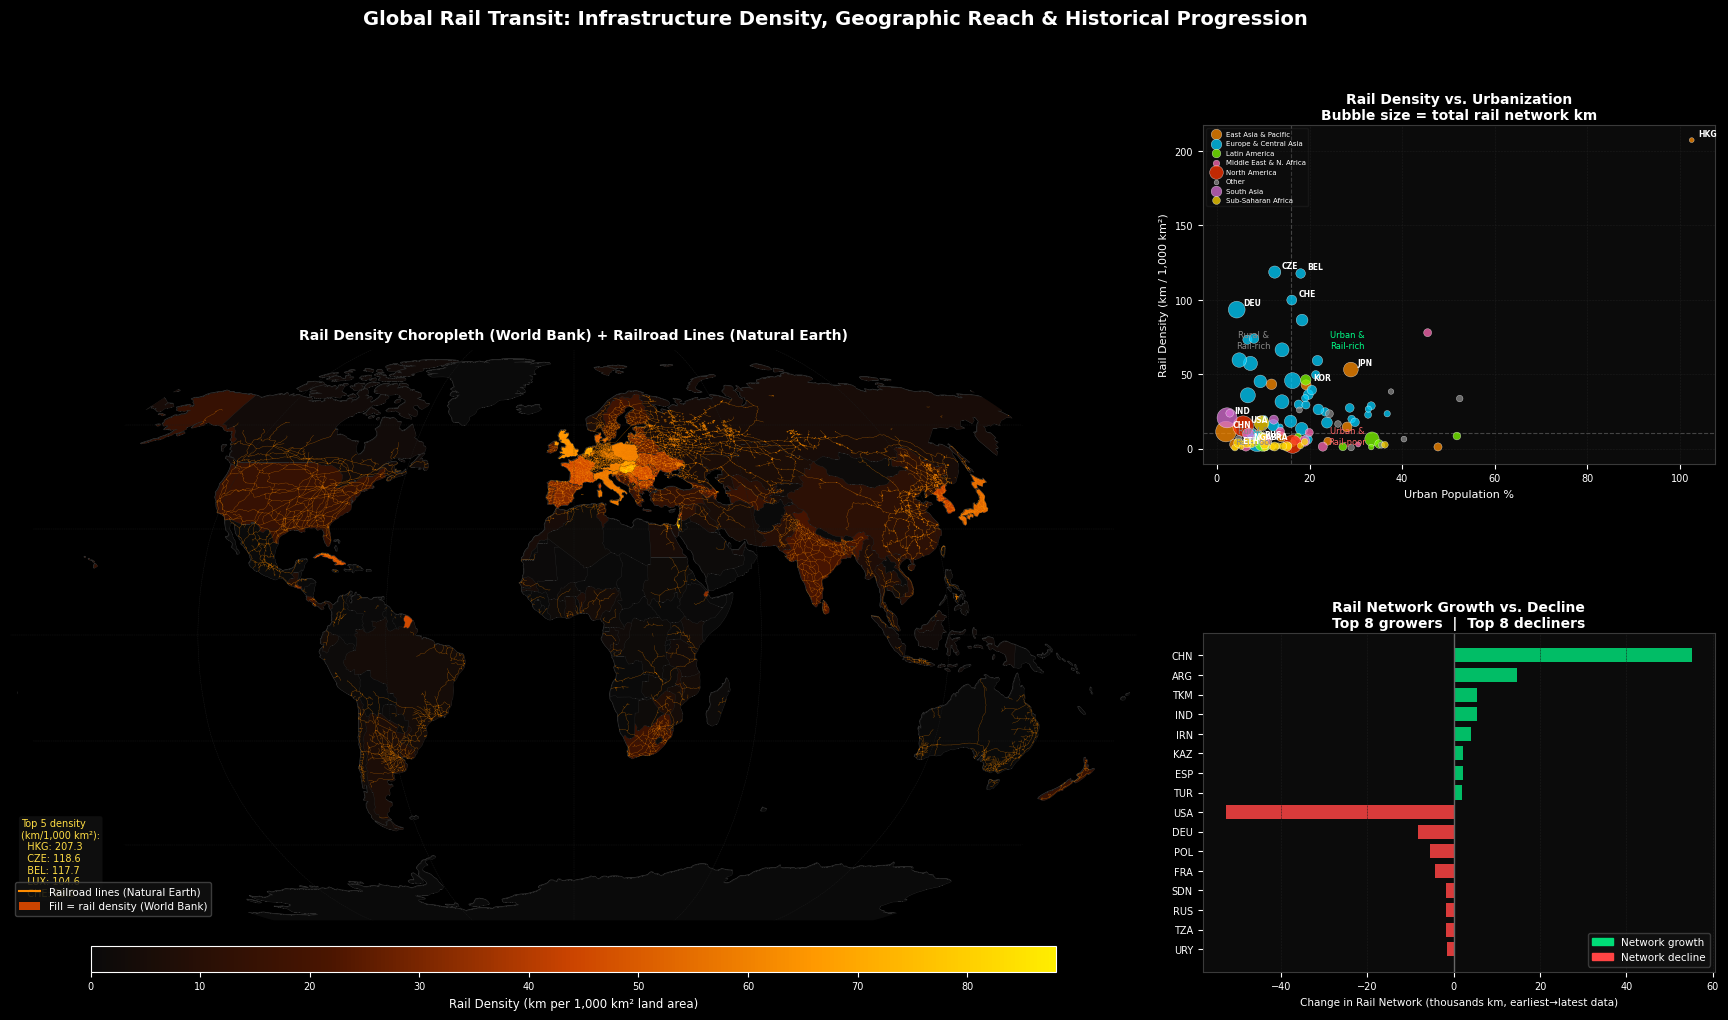


Bar chart check — combined rows: 16
   country    change_km
0      URY  -1504.00000
1      TZA  -1759.00000
2      RUS  -1844.00000
3      SDN  -1848.00000
4      FRA  -4281.00000
5      POL  -5366.00000
6      DEU  -8317.00000
7      USA -52730.65266
8      TUR   1997.00000
9      ESP   2107.00000
10     KAZ   2269.60000
11     IRN   4123.00000
12     IND   5442.73000
13     TKM   5527.00000
14     ARG  14716.00000
15     CHN  55151.00000


In [13]:
BG    = 'black'
TXT   = 'white'
COAST = '#3A3A3A'
GRID  = '#1C1C1C'
CMAP  = mcolors.LinearSegmentedColormap.from_list(
    'rail', ['#0A0A0A','#4B1500','#CC4400','#FF9900','#FFEE00'], N=256
)

fig = plt.figure(figsize=(22, 11), facecolor=BG)
fig.suptitle(
    'Global Rail Transit: Infrastructure Density, Geographic Reach & Historical Progression',
    color=TXT, fontsize=14, fontweight='bold', y=0.985
)
gs = gridspec.GridSpec(2, 2, figure=fig,
                       width_ratios=[2.2, 1], height_ratios=[1, 1],
                       wspace=0.08, hspace=0.50)

# ══ PANEL A: Map ══════════════════════════════════════════════════════════════
ax_map = fig.add_subplot(gs[:, 0], projection=ccrs.Robinson())
ax_map.set_facecolor(BG)
ax_map.set_global()
ax_map.coastlines(color=COAST, linewidth=0.5)
ax_map.gridlines(color=GRID, linewidth=0.3, linestyle='--')

vmin = 0
vmax = wb_latest['rail_density'].quantile(0.95)
for _, row in world_merged.iterrows():
    if row.geometry is None: continue
    val = row['rail_density'] if pd.notna(row['rail_density']) else 0
    nv  = min(max((val - vmin) / (vmax - vmin + 1e-9), 0), 1)
    try:
        ax_map.add_geometries(
            [row.geometry], crs=ccrs.PlateCarree(),
            facecolor=CMAP(nv), edgecolor='#2A2A2A', linewidth=0.2
        )
    except: pass

for geom in rail_lines.geometry:
    if geom is None: continue
    try:
        if geom.geom_type == 'LineString':
            ax_map.plot(*geom.xy, transform=ccrs.PlateCarree(),
                        color='#FF8C00', lw=0.25, alpha=0.55, zorder=3)
        elif geom.geom_type == 'MultiLineString':
            for part in geom.geoms:
                ax_map.plot(*part.xy, transform=ccrs.PlateCarree(),
                            color='#FF8C00', lw=0.25, alpha=0.55, zorder=3)
    except: pass

sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_map, orientation='horizontal',
                     pad=0.03, fraction=0.03, aspect=38)
cbar.set_label('Rail Density (km per 1,000 km² land area)', color=TXT, fontsize=8.5)
cbar.ax.xaxis.set_tick_params(color=TXT)
plt.setp(cbar.ax.xaxis.get_ticklabels(), color=TXT, fontsize=7)
cbar.outline.set_edgecolor(TXT)
ax_map.legend(
    handles=[
        Line2D([0],[0], color='#FF8C00', lw=1.5, label='Railroad lines (Natural Earth)'),
        mpatches.Patch(facecolor='#CC4400', label='Fill = rail density (World Bank)'),
    ],
    loc='lower left', fontsize=7.5,
    facecolor='#111', edgecolor='#444', labelcolor=TXT, framealpha=0.88
)
top5 = wb_latest.nlargest(5,'rail_density')[['country','rail_density']]
note = 'Top 5 density\n(km/1,000 km²):\n' + '\n'.join(
    f"  {r['country'][:14]}: {r['rail_density']:.1f}" for _,r in top5.iterrows())
ax_map.text(0.01, 0.04, note, transform=ax_map.transAxes,
            color='#FFDD44', fontsize=7, va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#111', alpha=0.88))
ax_map.set_title('Rail Density Choropleth (World Bank) + Railroad Lines (Natural Earth)',
                 color=TXT, fontsize=10, pad=7, fontweight='bold')

# ══ PANEL B: Bubble chart — rail density vs urban % by region ════════════════
# Bubble size = total rail km. Reveals: do urbanized countries build dense rail?
ax_sc = fig.add_subplot(gs[0, 1])
ax_sc.set_facecolor('#0B0B0B')
for sp in ax_sc.spines.values(): sp.set_edgecolor('#3A3A3A')
ax_sc.grid(True, color=GRID, lw=0.4, linestyle='--')

sc_df = wb_latest.dropna(subset=['rail_density','urban_pct','rail_km']).copy()
sc_df = sc_df[(sc_df['rail_density']>0) & (sc_df['urban_pct']>0)].copy()
sc_df['region'] = sc_df['region'].fillna('Other')
# Bubble size: sqrt scaling so large networks don't dominate
sc_df['bubble'] = np.sqrt(sc_df['rail_km']) * 0.8
sc_df['bubble'] = sc_df['bubble'].clip(lower=8, upper=220)

for region in sorted(sc_df['region'].unique()):
    mask  = sc_df['region'] == region
    color = RCOLS.get(region, '#888888')
    sub   = sc_df[mask]
    ax_sc.scatter(
        sub['urban_pct'], sub['rail_density'],
        s=sub['bubble'], color=color, alpha=0.75,
        label=region, edgecolors='white', linewidths=0.3, zorder=3
    )

# Quadrant lines — avg urban % and avg density
med_u = sc_df['urban_pct'].median()
med_r = sc_df['rail_density'].median()
ax_sc.axvline(med_u, color='#444444', lw=0.8, ls='--')
ax_sc.axhline(med_r, color='#444444', lw=0.8, ls='--')

# Quadrant labels
xlim = ax_sc.get_xlim(); ylim = ax_sc.get_ylim()
ax_sc.text(med_u*0.5, sc_df['rail_density'].quantile(0.92),
           'Rural &\nRail-rich', fontsize=6, color='#888', ha='center')
ax_sc.text(sc_df['urban_pct'].quantile(0.80),
           sc_df['rail_density'].quantile(0.92),
           'Urban &\nRail-rich', fontsize=6, color='#00FF88', ha='center')
ax_sc.text(sc_df['urban_pct'].quantile(0.80),
           med_r * 0.3,
           'Urban &\nRail-poor', fontsize=6, color='#FF6666', ha='center')
ax_sc.text(med_u*0.5, med_r * 0.3,
           'Rural &\nRail-poor', fontsize=6, color='#888', ha='center')

# Label notable countries
LABEL_ISO = {'CHE','BEL','CZE','DEU','JPN','CHN','IND','USA',
              'NGA','ETH','AUS','BRA','RUS','KOR','SGP','HKG'}
for _, row in sc_df.iterrows():
    if row.get('iso3','') in LABEL_ISO:
        ax_sc.annotate(
            row['iso3'],
            (row['urban_pct'], row['rail_density']),
            fontsize=5.5, color='white', fontweight='bold',
            xytext=(5, 3), textcoords='offset points'
        )

ax_sc.set_xlabel('Urban Population %', color=TXT, fontsize=8)
ax_sc.set_ylabel('Rail Density (km / 1,000 km²)', color=TXT, fontsize=8)
ax_sc.set_title('Rail Density vs. Urbanization\nBubble size = total rail network km',
                color=TXT, fontsize=10, pad=4, fontweight='bold')
ax_sc.tick_params(colors=TXT, labelsize=7)
ax_sc.legend(fontsize=5, framealpha=0.25, labelcolor=TXT,
             facecolor='#111', edgecolor='#3A3A3A',
             loc='upper left', markerscale=0.7,
             handletextpad=0.4, borderpad=0.4)

# ══ PANEL C: Growth vs Decline horizontal bar chart ════════════════════════════
ax_bar = fig.add_subplot(gs[1, 1])
ax_bar.set_facecolor('#0B0B0B')
for sp in ax_bar.spines.values(): sp.set_edgecolor('#3A3A3A')
ax_bar.grid(True, axis='x', color=GRID, lw=0.4, linestyle='--')
ax_bar.axvline(0, color='#666666', lw=1.0)

# Top 8 growers and top 8 decliners by absolute km change
growers   = change_df.nlargest(8,  'change_km').copy()
decliners = change_df.nsmallest(8, 'change_km').copy()

# Stack decliners on top, growers on bottom (sorted largest to smallest)
growers   = growers.sort_values('change_km', ascending=True)   
decliners = decliners.sort_values('change_km', ascending=False) 
combined  = pd.concat([decliners, growers], ignore_index=True)

y_pos  = range(len(combined))
colors = ['#00DD77' if v >= 0 else '#FF4444' for v in combined['change_km']]
labels = [r['country'][:14] if pd.notna(r['country']) else r['iso3']
          for _, r in combined.iterrows()]

ax_bar.barh(y_pos, combined['change_km'].values / 1000,
            color=colors, alpha=0.85, height=0.72, edgecolor='none')

ax_bar.set_yticks(list(y_pos))
ax_bar.set_yticklabels(labels, fontsize=6.5, color=TXT)
ax_bar.set_xlabel('Change in Rail Network (thousands km, earliest→latest data)',
                  color=TXT, fontsize=7.5)
ax_bar.set_title('Rail Network Growth vs. Decline\nTop 8 growers  |  Top 8 decliners',
                 color=TXT, fontsize=10, pad=4, fontweight='bold')
ax_bar.tick_params(colors=TXT, labelsize=7)
ax_bar.legend(
    handles=[
        mpatches.Patch(color='#00DD77', label='Network growth'),
        mpatches.Patch(color='#FF4444', label='Network decline'),
    ],
    fontsize=7.5, facecolor='#111', edgecolor='#444', labelcolor=TXT,
    loc='lower right'
)

plt.savefig('main_figure.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


print(f'\nBar chart check — combined rows: {len(combined)}')
print(combined[['country','change_km']].to_string())

## Cell 5 — Network: Country Rail Clusters by Region

Countries: 99
Node size range: 28–320
region
Europe & Central Asia      42
Sub-Saharan Africa         19
East Asia & Pacific        13
Latin America              10
Middle East & N. Africa     9
South Asia                  4
North America               2
Graph: 99 nodes, 120 edges


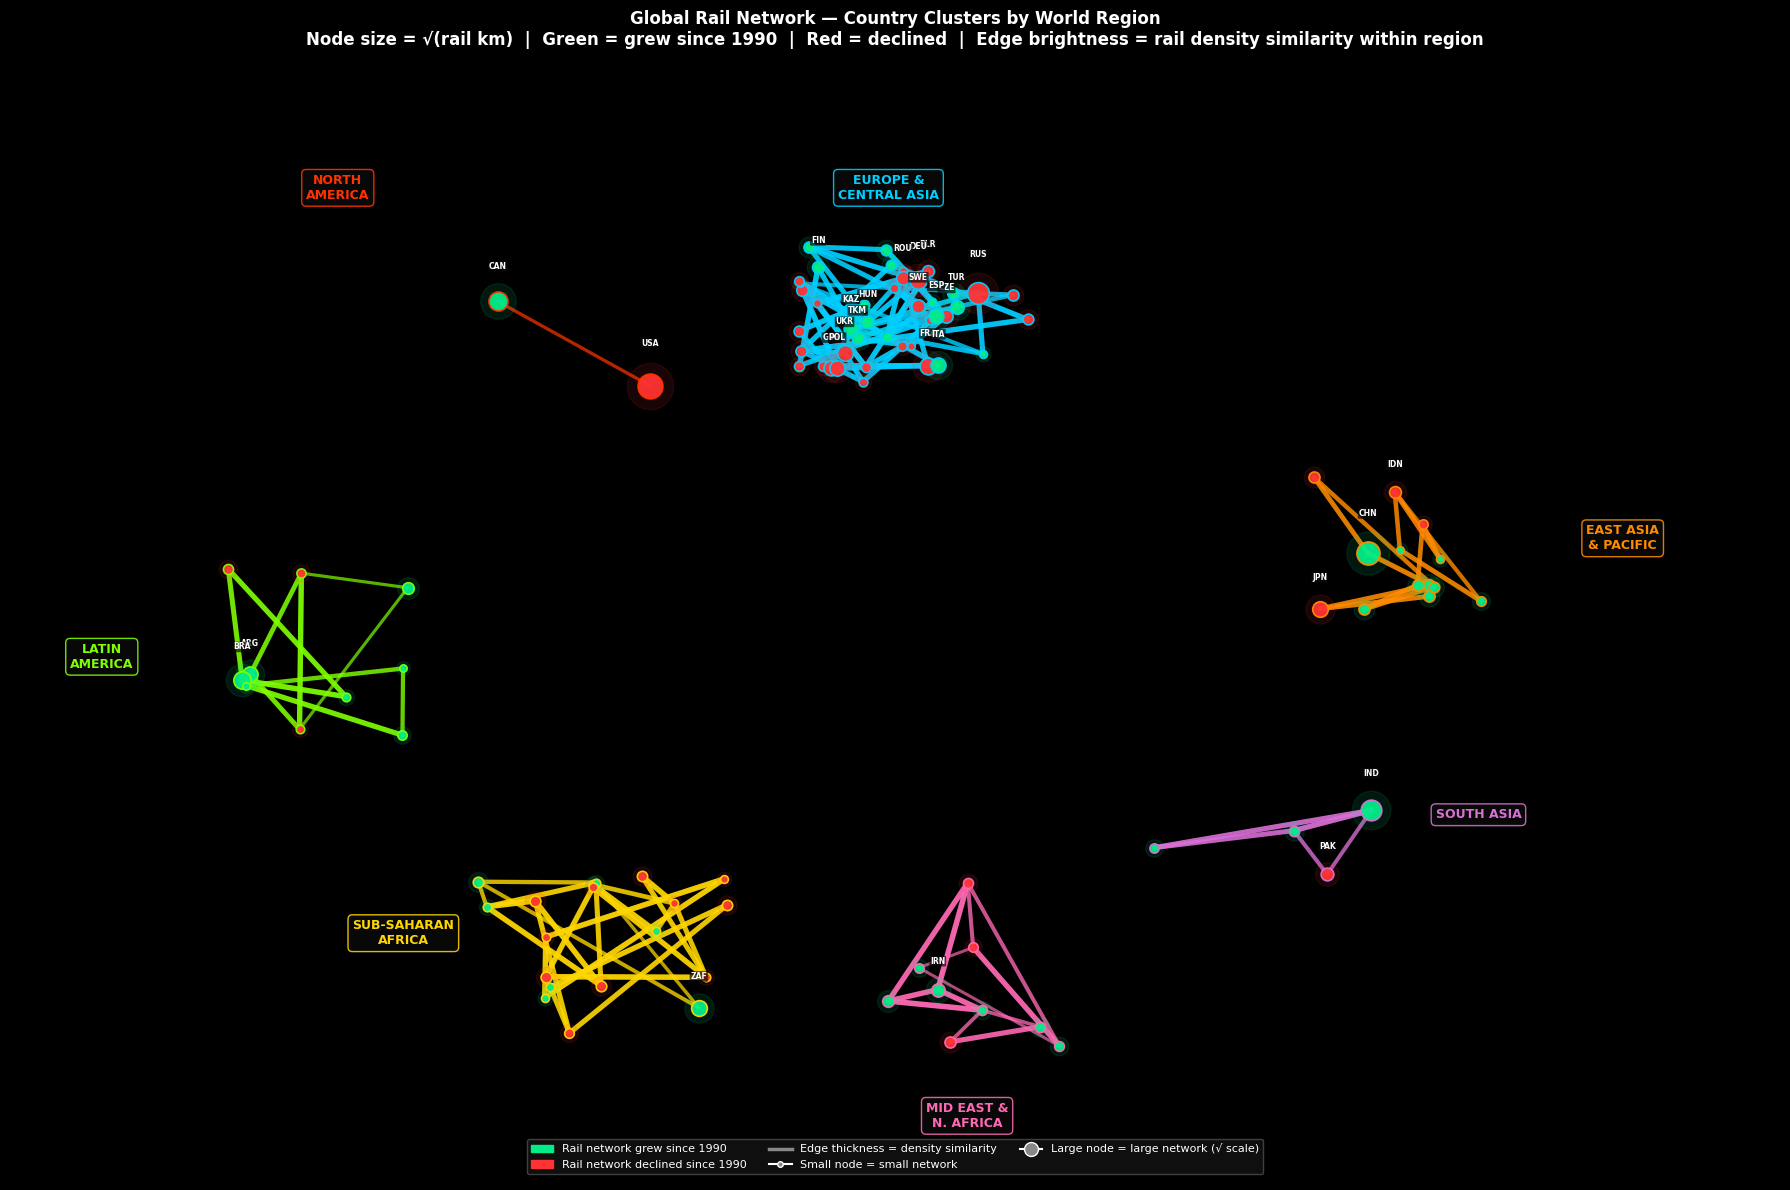

In [14]:
from collections import defaultdict

# ── Build net_src directly — no dependency on wb_latest columns ───────────────
#HAD AI help build a model for the network
rail_latest = (wb_df.dropna(subset=['rail_km'])
                    .sort_values('year', ascending=False)
                    .groupby('iso3').first()
                    .reset_index()
               [['iso3','country','rail_km','region']])

area_avg = (wb_df.dropna(subset=['area_km2'])
                 .groupby('iso3')['area_km2'].mean()
                 .rename('area_km2'))

rail_latest = rail_latest.join(area_avg, on='iso3', how='left')
rail_latest['rail_density'] = (rail_latest['rail_km'] /
                                rail_latest['area_km2'].clip(lower=1) * 1000)
rail_latest['rail_density'] = rail_latest['rail_density'].clip(lower=0.1).fillna(1.0)

# Apply region if missing
rail_latest['region'] = rail_latest['region'].fillna('Other')
# Use wb_latest region if available (it has the robust fallback from Cell 2)
if 'region' in wb_latest.columns:
    reg_map = wb_latest.set_index('iso3')['region']
    rail_latest['region'] = rail_latest['iso3'].map(reg_map).fillna(rail_latest['region'])

net_src = rail_latest[
    (rail_latest['rail_km'] > 300) &
    (rail_latest['region'] != 'Other')
].copy()

has_rail = wb_df.dropna(subset=['rail_km'])[['iso3','year','rail_km']]
first_r  = has_rail.sort_values('year').groupby('iso3')['rail_km'].first()
last_r   = has_rail.sort_values('year').groupby('iso3')['rail_km'].last()
delta    = (last_r - first_r).rename('delta_km')
net_src  = net_src.join(delta, on='iso3', how='left')
net_src['delta_km'] = net_src['delta_km'].fillna(0)

net_src['sqrt_km'] = np.sqrt(net_src['rail_km'])
s_min = net_src['sqrt_km'].min()
s_max = net_src['sqrt_km'].max()
net_src['node_size'] = 28 + ((net_src['sqrt_km'] - s_min) /
                               (s_max - s_min + 1e-9)) * 292

print(f'Countries: {len(net_src)}')
print(f'Node size range: {net_src["node_size"].min():.0f}–{net_src["node_size"].max():.0f}')
print(net_src.groupby('region').size().sort_values(ascending=False).to_string())


G3 = nx.Graph()
for _, r in net_src.iterrows():
    G3.add_node(str(r['iso3']),
                label     = str(r['country'])[:12],
                rail_km   = float(r['rail_km']),
                node_size = float(r['node_size']),
                density   = float(r['rail_density']),
                region    = str(r['region']),
                delta_km  = float(r['delta_km']))

by_region = defaultdict(list)
for n, d in G3.nodes(data=True):
    by_region[d['region']].append((n, d))

for region, members in by_region.items():
    if len(members) < 2:
        continue
    for n1, d1 in members:
        dists = sorted(
            [(abs(math.log1p(d1['density']) - math.log1p(d2['density'])), n2)
             for n2, d2 in members if n2 != n1]
        )
        for dist, n2 in dists[:2]:
            G3.add_edge(n1, n2, weight=round(1 / (1 + dist), 3))

print(f'Graph: {G3.number_of_nodes()} nodes, {G3.number_of_edges()} edges')


REGION_CENTERS = {
    'Europe & Central Asia':  ( 0.2,  3.2),
    'East Asia & Pacific':    ( 4.2,  1.0),
    'South Asia':             ( 3.2, -1.8),
    'Middle East & N. Africa':( 0.8, -3.5),
    'Sub-Saharan Africa':     (-2.0, -3.0),
    'Latin America':          (-4.2, -0.2),
    'North America':          (-2.5,  3.2),
}
SPREAD = 1.10
rng = np.random.default_rng(17)
pos3 = {}
for _, r in net_src.iterrows():
    cx, cy = REGION_CENTERS.get(str(r['region']), (0.0, 0.0))
    angle  = rng.uniform(0, 2 * math.pi)
    radius = rng.uniform(0.15, SPREAD)
    pos3[str(r['iso3'])] = (cx + radius * math.cos(angle),
                             cy + radius * math.sin(angle))

fig_net, ax_net = plt.subplots(figsize=(18, 12), facecolor=BG)
ax_net.set_facecolor(BG)
ax_net.set_title(
    'Global Rail Network — Country Clusters by World Region\n'
    'Node size = √(rail km)  |  Green = grew since 1990  |  Red = declined  |'
    '  Edge brightness = rail density similarity within region',
    color=TXT, fontsize=12, fontweight='bold', pad=14
)

# 1) Edges
all_w = [d['weight'] for _, _, d in G3.edges(data=True)]
max_w = max(all_w) if all_w else 1.0
for u, v, d in G3.edges(data=True):
    col  = RCOLS.get(G3.nodes[u]['region'], '#888')
    lw   = 1.2 + (d['weight'] / max_w) * 2.8
    alph = 0.55 + (d['weight'] / max_w) * 0.40
    ax_net.plot([pos3[u][0], pos3[v][0]],
                [pos3[u][1], pos3[v][1]],
                color=col, lw=lw, alpha=alph, zorder=2,
                solid_capstyle='round')

# 2) Glows
for n, d in G3.nodes(data=True):
    x, y = pos3[n]
    s    = d['node_size']
    fclr = '#00EE88' if d['delta_km'] >= 0 else '#FF3333'
    ax_net.scatter(x, y, s=s * 3.5, color=fclr, alpha=0.10, zorder=3)

# 3) Solid nodes
for n, d in G3.nodes(data=True):
    x, y = pos3[n]
    s    = d['node_size']
    fclr = '#00EE88' if d['delta_km'] >= 0 else '#FF3333'
    eclr = RCOLS.get(d['region'], '#888')
    ax_net.scatter(x, y, s=s, color=fclr,
                   edgecolors=eclr, linewidths=1.2,
                   alpha=0.95, zorder=4)

# 4) Country labels
top28   = set(net_src.nlargest(28, 'rail_km')['iso3'].astype(str))
big_chg = set(net_src[abs(net_src['delta_km']) > 5000]['iso3'].astype(str))
for n, d in G3.nodes(data=True):
    if n not in (top28 | big_chg):
        continue
    x, y = pos3[n]
    off  = (d['node_size'] ** 0.5) * 0.016 + 0.09
    ax_net.text(x, y + off, d['label'],
               fontsize=5.5, color='white', ha='center', va='bottom',
               fontweight='bold', zorder=5,
               bbox=dict(boxstyle='round,pad=0.1', facecolor='#0A0A0A',
                         alpha=0.70, edgecolor='none'))

# 5) Region labels
LABEL_POS = {
    'Europe & Central Asia':  ( 0.2,  4.55),
    'East Asia & Pacific':    ( 5.8,  1.0),
    'South Asia':             ( 4.7, -1.8),
    'Middle East & N. Africa':( 0.8, -4.85),
    'Sub-Saharan Africa':     (-3.5, -3.0),
    'Latin America':          (-5.8, -0.2),
    'North America':          (-4.0,  4.55),
}
SHORT = {
    'Europe & Central Asia':  'EUROPE &\nCENTRAL ASIA',
    'East Asia & Pacific':    'EAST ASIA\n& PACIFIC',
    'South Asia':             'SOUTH ASIA',
    'Middle East & N. Africa':'MID EAST &\nN. AFRICA',
    'Sub-Saharan Africa':     'SUB-SAHARAN\nAFRICA',
    'Latin America':          'LATIN\nAMERICA',
    'North America':          'NORTH\nAMERICA',
}
for region, (lx, ly) in LABEL_POS.items():
    col = RCOLS.get(region, '#888')
    ax_net.text(lx, ly, SHORT.get(region, region),
               fontsize=9, color=col, ha='center', va='center',
               fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.35', facecolor='#0A0A0A',
                         alpha=0.88, edgecolor=col, linewidth=1.0))

ax_net.legend(
    handles=[
        mpatches.Patch(color='#00EE88', label='Rail network grew since 1990'),
        mpatches.Patch(color='#FF3333', label='Rail network declined since 1990'),
        Line2D([0],[0], color='#888', lw=2.5,
               label='Edge thickness = density similarity'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#888',
               markersize=4,  label='Small node = small network'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#888',
               markersize=10, label='Large node = large network (√ scale)'),
    ],
    loc='lower center', ncol=3, fontsize=8,
    facecolor='#111', edgecolor='#444', labelcolor=TXT, framealpha=0.92
)
ax_net.set_xlim(-6.5, 7.0)
ax_net.set_ylim(-5.5, 5.8)
ax_net.axis('off')
plt.tight_layout()
plt.savefig('network_figure.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

## Cell 6 — PCA Country Embedding (Week 12) — region colors

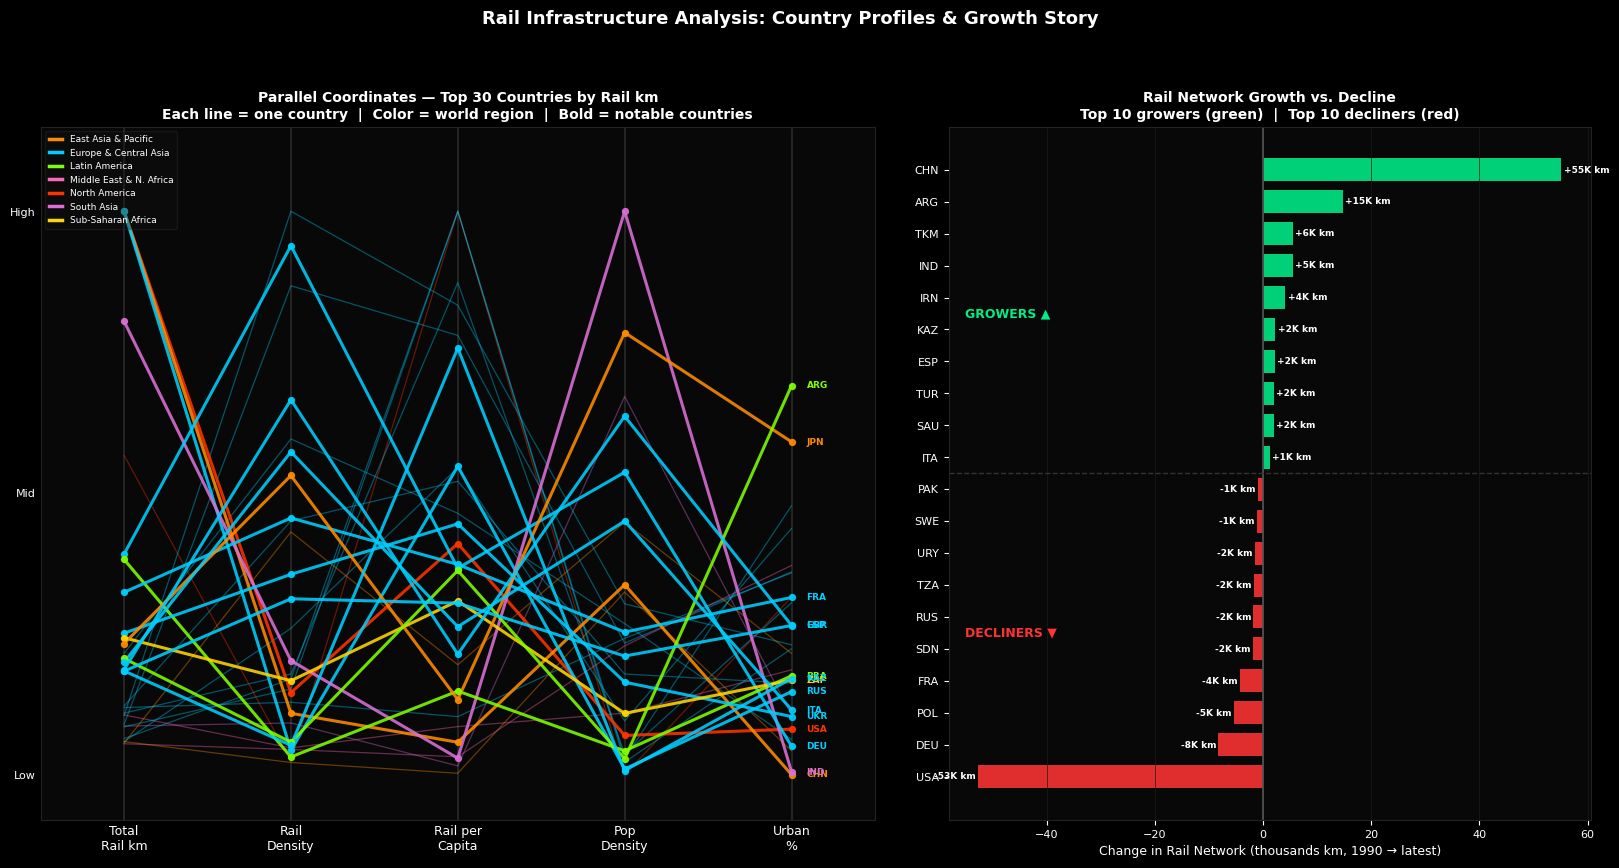

In [15]:
comp_df = wb_latest.dropna(subset=['rail_km']).copy()
comp_df = comp_df[comp_df['rail_km'] > 500].copy()
comp_df['region'] = comp_df['region'].fillna('Other')

if comp_df['rail_density'].isna().mean() > 0.4:
    area_lu = wb_df.dropna(subset=['area_km2']).groupby('iso3')['area_km2'].mean()
    comp_df = comp_df.join(area_lu.rename('area_fb'), on='iso3', how='left')
    mask = comp_df['rail_density'].isna()
    comp_df.loc[mask, 'rail_density'] = (
        comp_df.loc[mask,'rail_km'] / comp_df.loc[mask,'area_fb'] * 1000
    )
comp_df['rail_density']    = comp_df['rail_density'].fillna(0.1)
comp_df['rail_per_capita'] = comp_df['rail_per_capita'].fillna(0.0)
comp_df['pop_density']     = comp_df['pop_density'].fillna(0.0)
comp_df['urban_pct']       = comp_df['urban_pct'].fillna(0.0)

metrics = ['rail_km','rail_density','rail_per_capita','pop_density','urban_pct']
xlabels = ['Total\nRail km', 'Rail\nDensity', 'Rail per\nCapita',
           'Pop\nDensity', 'Urban\n%']
for m in metrics:
    lo = comp_df[m].quantile(0.02)
    hi = comp_df[m].quantile(0.98)
    comp_df[f'{m}_n'] = ((comp_df[m] - lo) / (hi - lo + 1e-9)).clip(0, 1)
norms = [f'{m}_n' for m in metrics]

# ── Figure ────────────────────────────────────────────────────────────────────
fig_ana = plt.figure(figsize=(20, 9), facecolor=BG)
gs_ana  = gridspec.GridSpec(1, 2, figure=fig_ana, wspace=0.10,
                             width_ratios=[1.3, 1])
fig_ana.suptitle('Rail Infrastructure Analysis: Country Profiles & Growth Story',
                 color=TXT, fontsize=13, fontweight='bold', y=1.01)

# ── LEFT: Parallel coordinates ────────────────────────────────────────────────
ax_par = fig_ana.add_subplot(gs_ana[0, 0])
ax_par.set_facecolor('#080808')
for sp in ax_par.spines.values(): sp.set_edgecolor('#222')
ax_par.set_xlim(-0.5, len(metrics)-0.5)
ax_par.set_ylim(-0.08, 1.15)

# Vertical axis lines
for i in range(len(metrics)):
    ax_par.axvline(i, color='#2A2A2A', lw=1.2, zorder=1)

top30 = comp_df.nlargest(30, 'rail_km').copy()

# NOTABLE countries for thick highlight lines
NOTABLE = {'CHN','USA','RUS','IND','DEU','FRA','JPN','CHE','BEL',
            'KOR','GBR','BRA','ARG','AUS','ZAF','KAZ','ESP','ITA','UKR'}

# Draw all lines — explicitly use matplotlib's plot with direct color string
for _, row in top30.iterrows():
    vals   = [row[n] for n in norms]
    region = row.get('region','Other')
    # Get color as explicit hex string — never pass list
    col = RCOLS.get(region, '#888888')
    is_notable = row['iso3'] in NOTABLE
    lw    = 2.2 if is_notable else 0.9
    alpha = 0.88 if is_notable else 0.38
    ax_par.plot(range(len(metrics)), vals,
                color=col, lw=lw, alpha=alpha, zorder=3 if is_notable else 2,
                solid_capstyle='round')
    if is_notable:
        # Dot at each axis
        for xi, yi in enumerate(vals):
            ax_par.scatter(xi, yi, s=18, color=col, zorder=4, alpha=0.9)
        # Label at right end
        ax_par.text(len(metrics)-1 + 0.09, vals[-1], row['iso3'],
                   fontsize=6.5, color=col, va='center', fontweight='bold')

ax_par.set_xticks(range(len(metrics)))
ax_par.set_xticklabels(xlabels, color=TXT, fontsize=9)
ax_par.set_yticks([0, 0.5, 1.0])
ax_par.set_yticklabels(['Low', 'Mid', 'High'], color='#888', fontsize=8)
ax_par.tick_params(colors=TXT, length=0)
ax_par.set_title(
    'Parallel Coordinates — Top 30 Countries by Rail km\n'
    'Each line = one country  |  Color = world region  |  Bold = notable countries',
    color=TXT, fontsize=10, fontweight='bold', pad=6)

# Legend — region colors
handles_par = [
    Line2D([0],[0], color=RCOLS[r], lw=2.5, label=r)
    for r in sorted(RCOLS.keys()) if r != 'Other'
]
ax_par.legend(handles=handles_par, fontsize=6.5, framealpha=0.35,
              labelcolor=TXT, facecolor='#111', edgecolor='#333',
              loc='upper left', ncol=1, handlelength=1.5)

# ── RIGHT: Diverging bar ──────────────────────────────────────────────────────
ax_bar = fig_ana.add_subplot(gs_ana[0, 1])
ax_bar.set_facecolor('#080808')
for sp in ax_bar.spines.values(): sp.set_edgecolor('#222')
ax_bar.grid(True, axis='x', color='#1C1C1C', lw=0.5)
ax_bar.axvline(0, color='#555', lw=1.2)

chg = change_df.copy()
chg['country'] = chg['country'].fillna(chg['iso3'])
chg['region']  = chg['region'].fillna('Other')
chg = chg[chg['rail_first'] > 200]

growers   = chg.nlargest(10, 'change_km').sort_values('change_km', ascending=True)
decliners = chg.nsmallest(10, 'change_km').sort_values('change_km', ascending=True)
combined  = pd.concat([decliners, growers], ignore_index=True)

y_pos  = list(range(len(combined)))
colors = ['#00EE88' if v >= 0 else '#FF3333' for v in combined['change_km']]
labels_bar = [str(r['country'])[:20] if pd.notna(r['country'])
              else str(r['iso3']) for _, r in combined.iterrows()]

ax_bar.barh(y_pos, combined['change_km'].values / 1000,
            color=colors, alpha=0.88, height=0.72, edgecolor='none')

# Value labels
for y, (_, row) in zip(y_pos, combined.iterrows()):
    val = row['change_km'] / 1000
    x   = val + (0.4 if val >= 0 else -0.4)
    ha  = 'left' if val >= 0 else 'right'
    ax_bar.text(x, y, f'{val:+.0f}K km',
               fontsize=6.5, color='white', va='center', ha=ha,
               fontweight='bold')

ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(labels_bar, fontsize=8, color=TXT)
ax_bar.set_xlabel('Change in Rail Network (thousands km, 1990 → latest)',
                  color=TXT, fontsize=9)
ax_bar.set_title(
    'Rail Network Growth vs. Decline\nTop 10 growers (green)  |  Top 10 decliners (red)',
    color=TXT, fontsize=10, fontweight='bold', pad=6)
ax_bar.tick_params(colors=TXT, labelsize=8)

# Divider + section labels
ax_bar.axhline(9.5, color='#333', lw=1.0, ls='--')
xlim = ax_bar.get_xlim()
ax_bar.text(xlim[0] * 0.95, 14.5, 'GROWERS ▲',
           fontsize=9, color='#00EE88', fontweight='bold', va='center')
ax_bar.text(xlim[0] * 0.95,  4.5, 'DECLINERS ▼',
           fontsize=9, color='#FF3333', fontweight='bold', va='center')

plt.savefig('pca_figure.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

## Cell 7 — Key Findings

In [16]:

print('KEY FINDINGS')
print(f'  World Bank rows:    {len(wb_df):,}  ({wb_df.year.min()}–{wb_df.year.max()})')
print(f'  Countries tracked:  {len(wb_latest)}')
print(f'  NE rail segments:   {len(rail_lines):,}')
print(f'  Countries growing:  {(change_df["change_km"]>0).sum()}')
print(f'  Countries declining:{(change_df["change_km"]<0).sum()}')
print('\n  Largest networks:')
for _,r in wb_latest.nlargest(5,'rail_km')[['country','rail_km']].iterrows():
    print(f'    {r["country"]:24s}: {r["rail_km"]:>8,.0f} km')
print('\n  Densest networks (km/1,000km²):')
for _,r in wb_latest.nlargest(5,'rail_density')[['country','rail_density']].iterrows():
    print(f'    {r["country"]:24s}: {r["rail_density"]:>6.1f}')
print('\n  Biggest growers (km added):')
for _,r in change_df.nlargest(5,'change_km')[['country','change_km','change_pct']].iterrows():
    print(f'    {r["country"]:24s}: +{r["change_km"]:>7,.0f} km  (+{r["change_pct"]:.0f}%)')
print('\n  Biggest decliners (km lost):')
for _,r in change_df.nsmallest(5,'change_km')[['country','change_km','change_pct']].iterrows():
    print(f'    {r["country"]:24s}: {r["change_km"]:>8,.0f} km  ({r["change_pct"]:.0f}%)')
print('='*65)

KEY FINDINGS
  World Bank rows:    8,778  (1990–2022)
  Countries tracked:  116
  NE rail segments:   25,413
  Countries growing:  40
  Countries declining:48

  Largest networks:
    USA                     :  148,553 km
    CHN                     :  109,767 km
    RUS                     :   85,544 km
    IND                     :   68,103 km
    CAN                     :   48,150 km

  Densest networks (km/1,000km²):
    HKG                     :  207.3
    CZE                     :  118.6
    BEL                     :  117.7
    LUX                     :  104.6
    CHE                     :   99.8

  Biggest growers (km added):
    CHN                     : + 55,151 km  (+101%)
    ARG                     : + 14,716 km  (+467%)
    TKM                     : +  5,527 km  (+257%)
    IND                     : +  5,443 km  (+9%)
    IRN                     : +  4,123 km  (+77%)

  Biggest decliners (km lost):
    USA                     :  -52,731 km  (-26%)
    DEU                  

## Cell 8 — Global HSR Network: Corridors, Connectivity & Isolation Gaps
A multi-layered map showing:
- **Country fill** — 4-tier HSR threshold classification
- **Intra-network corridors** — thick gold arcs connecting major hubs WITHIN networks
- **Cross-border connections** — dashed cyan arcs where HSR crosses national borders
- **Isolated major cities** — red halos on large population centers with NO HSR access
- **HSR gap zones** — annotated regions that are geographically large with zero HSR
- **Hub dots** — three-layer glow scaled by network size

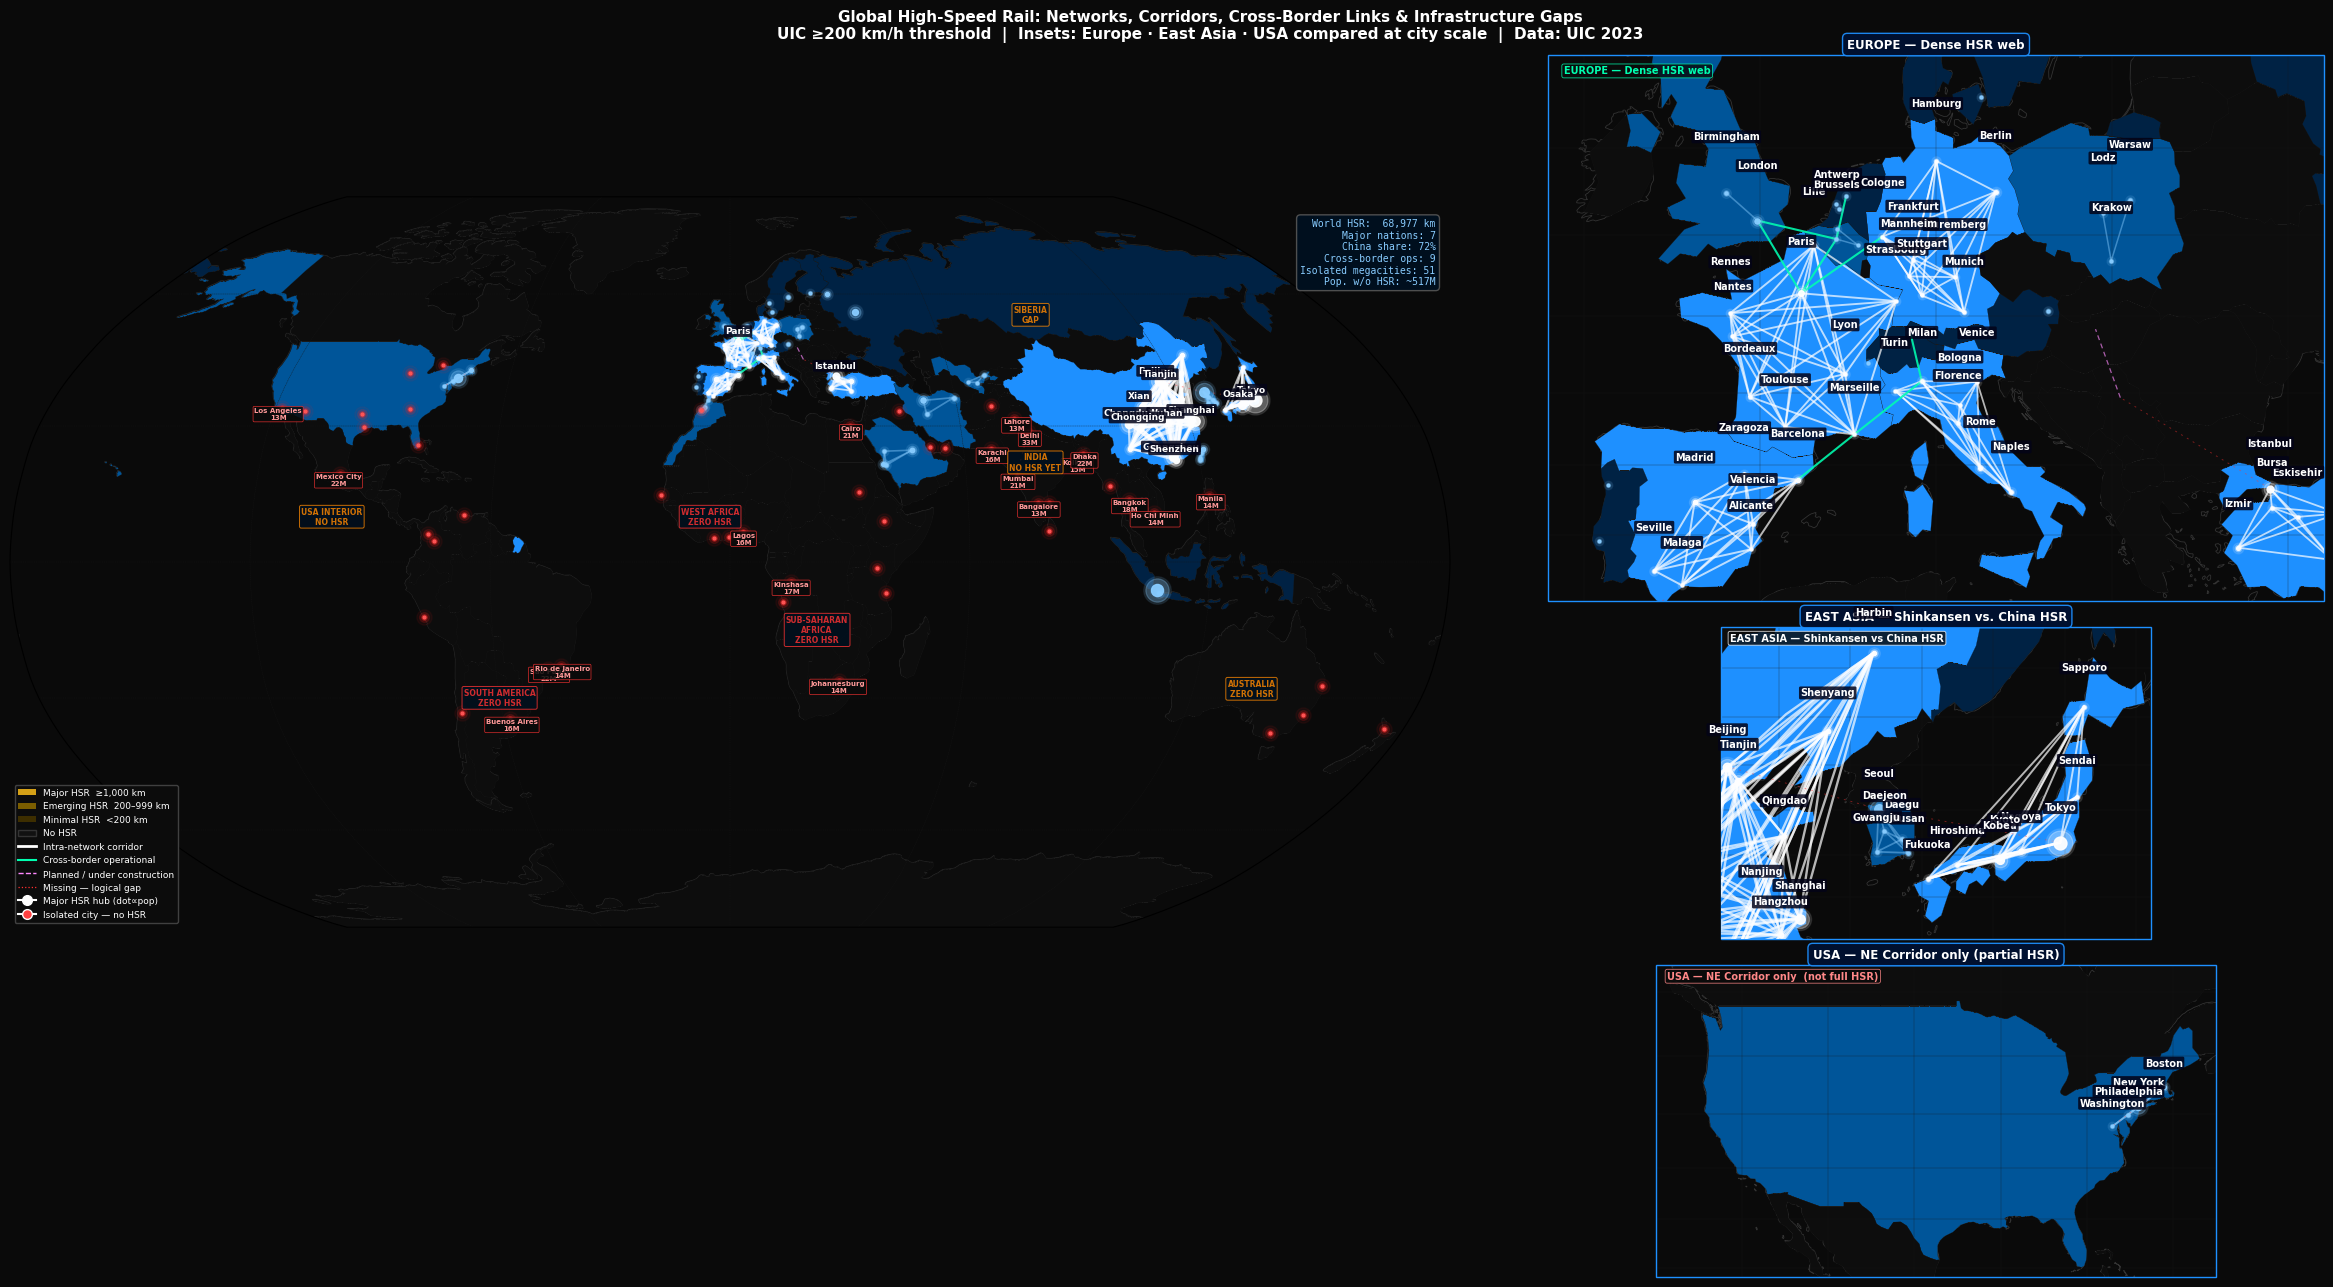


Hub cities: 113
Isolated cities: 51
Cross-border routes: 16


In [17]:
import itertools

#HSR data: (country, total km, year of first HSR line, max speed km/h)
HSR_DATA = {
    'CHN': ('China',          50000, 2008, 350),
    'ESP': ('Spain',           3973, 1992, 310),
    'JPN': ('Japan',           3081, 1964, 320),
    'FRA': ('France',          2734, 1981, 320),
    'DEU': ('Germany',         1571, 1991, 300),
    'TUR': ('Turkey',          1213, 2009, 250),
    'ITA': ('Italy',           1007, 1977, 300),
    'KOR': ('South Korea',      887, 2004, 305),
    'GBR': ('United Kingdom',   432, 2003, 300),
    'IRN': ('Iran',             926, 2004, 200),
    'SAU': ('Saudi Arabia',     453, 2018, 300),
    'TWN': ('Taiwan',           345, 2007, 300),
    'UZB': ('Uzbekistan',       344, 2011, 250),
    'USA': ('United States',    735, 2000, 241),
    'POL': ('Poland',           224, 2014, 200),
    'BEL': ('Belgium',          209, 1997, 300),
    'MAR': ('Morocco',          200, 2018, 320),
    'IDN': ('Indonesia',        142, 2023, 350),
    'NLD': ('Netherlands',      120, 2009, 300),
    'RUS': ('Russia',           137, 2009, 250),
    'SWE': ('Sweden',            90, 1997, 200),
    'AUT': ('Austria',           60, 2012, 250),
    'CHE': ('Switzerland',       35, 2004, 200),
    'DNK': ('Denmark',           25, 2019, 200),
    'FIN': ('Finland',           20, 2006, 220),
    'PRT': ('Portugal',          14, 2010, 220),
}

# ── HSR hub cities (city, iso3, lat, lon, pop_M) ───────────────────────────── Had AI help with this algorithm  
HSR_HUBS = [

    ('Beijing',    'CHN',  39.90, 116.40, 21.5),
    ('Shanghai',   'CHN',  31.23, 121.47, 24.9),
    ('Guangzhou',  'CHN',  23.13, 113.26, 18.7),
    ('Wuhan',      'CHN',  30.59, 114.31, 12.3),
    ('Chengdu',    'CHN',  30.57, 104.07, 20.9),
    ('Xian',       'CHN',  34.27, 108.95, 12.9),
    ('Zhengzhou',  'CHN',  34.75, 113.62,  9.0),
    ('Hangzhou',   'CHN',  30.25, 120.15,  8.0),
    ('Nanjing',    'CHN',  32.06, 118.77,  8.5),
    ('Shenzhen',   'CHN',  22.54, 114.06, 13.0),
    ('Tianjin',    'CHN',  39.13, 117.18, 13.9),
    ('Chongqing',  'CHN',  29.56, 106.55, 16.9),
    ('Harbin',     'CHN',  45.75, 126.63,  5.9),
    ('Shenyang',   'CHN',  41.80, 123.43,  7.9),
    ('Kunming',    'CHN',  25.04, 102.71,  5.5),
    ('Qingdao',    'CHN',  36.07, 120.38,  5.7),

    ('Tokyo',      'JPN',  35.69, 139.69, 37.4),
    ('Osaka',      'JPN',  34.69, 135.50, 19.1),
    ('Nagoya',     'JPN',  35.18, 136.91,  9.5),
    ('Hiroshima',  'JPN',  34.39, 132.46,  2.9),
    ('Fukuoka',    'JPN',  33.59, 130.42,  2.5),
    ('Sendai',     'JPN',  38.27, 140.87,  2.2),
    ('Sapporo',    'JPN',  43.06, 141.35,  2.0),
    ('Kyoto',      'JPN',  35.01, 135.77,  1.5),
    ('Kobe',       'JPN',  34.69, 135.19,  1.5),

    ('Seoul',      'KOR',  37.57, 126.98, 25.5),
    ('Busan',      'KOR',  35.10, 129.04,  3.5),
    ('Daegu',      'KOR',  35.87, 128.60,  2.5),
    ('Gwangju',    'KOR',  35.16, 126.85,  1.5),
    ('Daejeon',    'KOR',  36.35, 127.38,  1.5),
  
    ('Taipei',     'TWN',  25.04, 121.56,  7.0),
    ('Taichung',   'TWN',  24.15, 120.68,  2.8),
    ('Kaohsiung',  'TWN',  22.63, 120.31,  2.7),
    ('Tainan',     'TWN',  22.99, 120.22,  1.9),

    ('Madrid',     'ESP',  40.42,  -3.70,  6.7),
    ('Barcelona',  'ESP',  41.39,   2.15,  5.6),
    ('Seville',    'ESP',  37.39,  -5.99,  1.9),
    ('Valencia',   'ESP',  39.47,  -0.38,  1.6),
    ('Malaga',     'ESP',  36.72,  -4.42,  0.6),
    ('Zaragoza',   'ESP',  41.65,  -0.88,  0.7),
    ('Alicante',   'ESP',  38.35,  -0.48,  0.3),

    ('Paris',      'FRA',  48.86,   2.35, 11.1),
    ('Lyon',       'FRA',  45.75,   4.85,  1.7),
    ('Marseille',  'FRA',  43.30,   5.37,  1.6),
    ('Bordeaux',   'FRA',  44.84,  -0.58,  0.9),
    ('Toulouse',   'FRA',  43.60,   1.44,  0.9),
    ('Lille',      'FRA',  50.63,   3.07,  1.0),
    ('Nantes',     'FRA',  47.22,  -1.55,  0.6),
    ('Strasbourg', 'FRA',  48.57,   7.75,  0.5),
    ('Rennes',     'FRA',  48.11,  -1.68,  0.4),

    ('Frankfurt',  'DEU',  50.11,   8.68,  0.8),
    ('Cologne',    'DEU',  50.94,   6.96,  1.1),
    ('Munich',     'DEU',  48.14,  11.58,  1.5),
    ('Hamburg',    'DEU',  53.57,  10.02,  1.8),
    ('Berlin',     'DEU',  52.52,  13.40,  3.7),
    ('Stuttgart',  'DEU',  48.78,   9.18,  0.6),
    ('Nuremberg',  'DEU',  49.46,  11.08,  0.5),
    ('Mannheim',   'DEU',  49.49,   8.47,  0.3),
  
    ('Rome',       'ITA',  41.90,  12.50,  4.3),
    ('Milan',      'ITA',  45.46,   9.19,  3.2),
    ('Naples',     'ITA',  40.85,  14.27,  3.1),
    ('Florence',   'ITA',  43.77,  11.25,  0.9),
    ('Turin',      'ITA',  45.07,   7.69,  0.9),
    ('Bologna',    'ITA',  44.50,  11.34,  0.4),
    ('Venice',     'ITA',  45.44,  12.33,  0.3),
    
    ('London',     'GBR',  51.51,  -0.13,  9.5),
    ('Birmingham', 'GBR',  52.48,  -1.90,  2.6),

    ('Istanbul',   'TUR',  41.01,  28.95, 15.5),
    ('Ankara',     'TUR',  39.93,  32.86,  5.7),
    ('Konya',      'TUR',  37.87,  32.49,  2.2),
    ('Eskisehir',  'TUR',  39.78,  30.52,  0.7),
    ('Bursa',      'TUR',  40.19,  29.06,  1.7),
    ('Izmir',      'TUR',  38.42,  27.14,  4.4),

    ('Brussels',   'BEL',  50.85,   4.35,  1.2),
    ('Antwerp',    'BEL',  51.22,   4.40,  0.5),
    ('Liege',      'BEL',  50.63,   5.57,  0.2),
    ('Amsterdam',  'NLD',  52.37,   4.90,  0.9),
    ('Rotterdam',  'NLD',  51.92,   4.48,  0.7),
    ('The Hague',  'NLD',  52.08,   4.30,  0.5),

    ('Warsaw',     'POL',  52.23,  21.01,  1.8),
    ('Krakow',     'POL',  50.06,  19.94,  0.8),
    ('Lodz',       'POL',  51.77,  19.46,  0.7),

    ('Riyadh',     'SAU',  24.69,  46.72,  7.7),
    ('Mecca',      'SAU',  21.39,  39.86,  2.0),
    ('Medina',     'SAU',  24.47,  39.61,  1.5),
    ('Jeddah',     'SAU',  21.54,  39.17,  4.7),

    ('Tashkent',   'UZB',  41.30,  69.24,  2.7),
    ('Samarkand',  'UZB',  39.65,  66.97,  0.6),
    ('Bukhara',    'UZB',  39.77,  64.42,  0.3),

    ('Tehran',     'IRN',  35.69,  51.39,  9.5),
    ('Isfahan',    'IRN',  32.66,  51.68,  2.2),
    ('Mashhad',    'IRN',  36.30,  59.60,  3.4),

    ('Casablanca', 'MAR',  33.59,  -7.62,  4.3),
    ('Tangier',    'MAR',  35.78,  -5.80,  1.1),
    ('Rabat',      'MAR',  34.02,  -6.83,  0.6),
    ('Kenitra',    'MAR',  34.26,  -6.58,  0.4),

    ('New York',   'USA',  40.71, -74.01, 20.1),
    ('Washington', 'USA',  38.91, -77.04,  0.7),
    ('Boston',     'USA',  42.36, -71.06,  4.9),
    ('Philadelphia','USA', 39.95, -75.17,  1.6),

    ('Jakarta',    'IDN',  -6.21, 106.85, 34.5),
    ('Bandung',    'IDN',  -6.92, 107.61,  2.5),

    ('Moscow',     'RUS',  55.75,  37.62, 12.5),
    ('St Peters',  'RUS',  59.94,  30.32,  5.4),

    ('Stockholm',  'SWE',  59.33,  18.07,  2.4),
    ('Gothenburg', 'SWE',  57.71,  11.97,  0.6),

    ('Vienna',     'AUT',  48.21,  16.37,  1.9),
    ('Zurich',     'CHE',  47.38,   8.54,  0.4),
    ('Geneva',     'CHE',  46.20,   6.14,  0.2),

    ('Copenhagen', 'DNK',  55.68,  12.57,  0.8),
    ('Helsinki',   'FIN',  60.17,  24.94,  0.6),

    ('Lisbon',     'PRT',  38.72,  -9.14,  0.5),
    ('Porto',      'PRT',  41.15,  -8.61,  0.2),
]


CROSS_BORDER = [
    (51.51, -0.13, 48.86,  2.35, 'London–Paris',     'operational'),
    (51.51, -0.13, 50.85,  4.35, 'London–Brussels',  'operational'),
    (48.86,  2.35, 50.85,  4.35, 'Paris–Brussels',   'operational'),
    (50.85,  4.35, 52.37,  4.90, 'Brussels–Amsterdam','operational'),
    (48.86,  2.35, 50.94,  6.96, 'Paris–Cologne',    'operational'),
    (41.39,  2.15, 43.30,  5.37, 'Barcelona–Marseille','operational'),
    (45.46,  9.19, 43.30,  5.37, 'Milan–Marseille',  'operational'),
    (45.46,  9.19, 47.38,  8.54, 'Milan–Zurich',     'operational'),
    (23.13, 113.26, 22.30, 114.17,'Guangzhou–HK',    'operational'),
    (44.80, 20.46,  47.50, 19.05, 'Belgrade–Budapest','planned'),

    (35.69, 139.69, 37.57, 126.98,'Tokyo–Seoul GAP',  'missing'),
    (37.57, 126.98, 39.90, 116.40,'Seoul–Beijing GAP','missing'),
    (41.01,  28.95, 44.80,  20.46,'Istanbul–Belgrade GAP','missing'),
    (35.78,  -5.80, 36.13,  -5.35,'Tangier–Spain GAP','missing'),
    (28.61,  77.21, 19.08,  72.88,'Delhi–Mumbai GAP', 'missing'),
    (42.36, -71.06, 38.91, -77.04,'Boston–DC (partial)','missing'),
]

ISOLATED_CITIES = [

    ('Lagos',           6.52,   3.38,  15.9),
    ('Cairo',          30.04,  31.24,  21.3),
    ('Kinshasa',       -4.32,  15.32,  17.1),
    ('Johannesburg',  -26.20,  28.04,  14.2),
    ('Nairobi',        -1.29,  36.82,   5.0),
    ('Dar es Salaam',  -6.79,  39.20,   7.4),
    ('Addis Ababa',     9.03,  38.74,   5.5),
    ('Khartoum',       15.55,  32.53,   6.2),
    ('Luanda',         -8.84,  13.23,   8.3),
    ('Abidjan',         5.36,  -4.01,   5.3),
    ('Accra',           5.56,  -0.20,   3.6),
    ('Dakar',          14.72, -17.47,   3.7),
    ('Casablanca',     33.59,  -7.62,   4.3),  

    ('São Paulo',     -23.55, -46.63,  22.4),
    ('Buenos Aires',  -34.60, -58.38,  15.5),
    ('Lima',          -12.05, -77.05,  11.2),
    ('Bogotá',          4.71, -74.07,  11.0),
    ('Rio de Janeiro', -22.91, -43.17,  13.6),
    ('Santiago',      -33.45, -70.67,   7.0),
    ('Caracas',        10.48, -66.88,   3.0),
    ('Medellin',        6.25, -75.56,   4.0),

    ('Mumbai',         19.08,  72.88,  20.7),
    ('Delhi',          28.61,  77.21,  32.9),
    ('Kolkata',        22.57,  88.36,  14.9),
    ('Chennai',        13.08,  80.27,  10.9),
    ('Bangalore',      12.97,  77.59,  12.8),
    ('Dhaka',          23.81,  90.41,  22.4),
    ('Karachi',        24.86,  67.01,  16.1),
    ('Lahore',         31.55,  74.35,  13.1),
    ('Manila',         14.60, 120.98,  14.4),
    ('Bangkok',        13.75, 100.52,  17.6),
    ('Ho Chi Minh',    10.82, 106.63,  13.5),
    ('Yangon',         16.87,  96.19,   7.4),
    ('Colombo',         6.93,  79.85,   0.8),

    ('Mexico City',    19.43, -99.13,  21.6),
    ('Chicago',        41.88, -87.63,   9.5),
    ('Los Angeles',    34.05,-118.24,  13.2),
    ('Houston',        29.76, -95.37,   7.3),
    ('Toronto',        43.65, -79.38,   6.4),
    ('Miami',          25.77, -80.19,   6.2),
    ('Atlanta',        33.75, -84.39,   6.1),
    ('Dallas',         32.78, -96.80,   7.7),
    ('Phoenix',        33.45,-112.07,   5.1),

    ('Sydney',        -33.87, 151.21,   5.3),
    ('Melbourne',     -37.81, 144.96,   5.0),
    ('Brisbane',      -27.47, 153.02,   2.5),
    ('Auckland',      -36.86, 174.77,   1.7),

    ('Baghdad',        33.34,  44.40,   7.7),
    ('Kabul',          34.52,  69.18,   4.6),
    ('Doha',           25.29,  51.53,   0.6),
    ('Dubai',          25.20,  55.27,   3.6),
]

GAP_ZONES = [
    (-15,  22, 'SUB-SAHARAN\nAFRICA\nZERO HSR',     '#FF3333'),
    (-30, -60, 'SOUTH AMERICA\nZERO HSR',            '#FF3333'),
    ( 22,  78, 'INDIA\nNO HSR YET',                  '#FF8800'),
    (-28, 135, 'AUSTRALIA\nZERO HSR',                '#FF8800'),
    ( 55,  90, 'SIBERIA\nGAP',                       '#FF8800'),
    ( 10,  -5, 'WEST AFRICA\nZERO HSR',              '#FF3333'),
    ( 10, -100,'USA INTERIOR\nNO HSR',               '#FF8800'),
]

hsr_df  = pd.DataFrame.from_dict(
    HSR_DATA, orient='index',
    columns=['country','hsr_km','year_first','max_speed']
)
hsr_df.index.name = 'iso3'
hsr_df  = hsr_df.reset_index()

hubs_df = pd.DataFrame(HSR_HUBS, columns=['city','iso3','lat','lon','pop_m'])
hubs_df = hubs_df.merge(hsr_df[['iso3','hsr_km','max_speed']], on='iso3', how='left')

def hsr_class(km):
    if km >= 1000: return 'Major'
    if km >=  200: return 'Emerging'
    if km >    0:  return 'Minimal'
    return 'None'

hsr_df['hsr_class'] = hsr_df['hsr_km'].apply(hsr_class)
world_hsr = world.merge(
    hsr_df[['iso3','hsr_km','hsr_class','year_first','max_speed']],
    on='iso3', how='left'
)
world_hsr['hsr_km']    = world_hsr['hsr_km'].fillna(0)
world_hsr['hsr_class'] = world_hsr['hsr_class'].fillna('None')

CLASS_COLORS = {
    'Major':    '#1E90FF',   # bright blue — immediately stands out
    'Emerging': '#005599',   # medium blue
    'Minimal':  '#002244',   # dark navy
    'None':     '#0D0D0D',   # near black
}
EDGE_COL  = '#FFFFFF'   # white corridors — max contrast on blue
XBDR_COL  = '#00FFB0'   # bright teal cross-border
PLAN_COL  = '#FF88FF'   # magenta planned
MISS_COL  = '#FF3030'   # red missing
HUB_MAJ   = '#FFFFFF'   # white hub dots — pop on blue
HUB_EMR   = '#88CCFF'   # light blue emerging

fig_hsr = plt.figure(figsize=(24, 13), facecolor='#0A0A0A')
fig_hsr.patch.set_facecolor('#0A0A0A')

ax_main = fig_hsr.add_axes([0.0, 0.18, 0.60, 0.78],
                            projection=ccrs.Robinson())
ax_main.set_facecolor('#0A0A0A')
ax_main.set_global()
ax_main.coastlines(color='#2A2A2A', linewidth=0.5)
ax_main.gridlines(color='#161616', linewidth=0.25, linestyle='--')

ax_eu  = fig_hsr.add_axes([0.615, 0.54, 0.375, 0.42],
                           projection=ccrs.Mercator())
ax_sea = fig_hsr.add_axes([0.615, 0.28, 0.375, 0.24],
                           projection=ccrs.Mercator())
ax_usa = fig_hsr.add_axes([0.615, 0.02, 0.375, 0.24],
                           projection=ccrs.Mercator())

INSET_BOUNDS = {
    'eu':  (-12, 32, 36, 57),   # W, E, S, N
    'sea': (116, 146, 30, 47),  # East Asia
    'usa': (-130, -65, 24, 52),
}

for ax_ins, key in [(ax_eu,'eu'),(ax_sea,'sea'),(ax_usa,'usa')]:
    ax_ins.set_facecolor('#0A0A0A')
    w,e,s,n = INSET_BOUNDS[key]
    ax_ins.set_extent([w,e,s,n], crs=ccrs.PlateCarree())
    ax_ins.coastlines(color='#333', linewidth=0.6)
    ax_ins.add_feature(__import__('cartopy.feature', fromlist=['BORDERS']).BORDERS,
                       linewidth=0.4, edgecolor='#222', facecolor='none')
    ax_ins.gridlines(color='#1A1A1A', linewidth=0.2)

INSET_TITLES = {
    ax_eu:  'EUROPE — Dense HSR web',
    ax_sea: 'EAST ASIA — Shinkansen vs. China HSR',
    ax_usa: 'USA — NE Corridor only (partial HSR)',
}
for ax_ins, title in INSET_TITLES.items():
    ax_ins.set_title(title, color='white', fontsize=8.5,
                     fontweight='bold', pad=5,
                     bbox=dict(facecolor='#001133', alpha=0.92,
                               edgecolor='#1E90FF', boxstyle='round,pad=0.4'))

ALL_AXES = [ax_main] + [ax_eu, ax_sea, ax_usa]

# ── LAYER 1: Country fill ─────────────────────────────────────────────────────
for ax in ALL_AXES:
    for _, row in world_hsr.iterrows():
        if row.geometry is None: continue
        color = CLASS_COLORS[row['hsr_class']]
        try:
            ax.add_geometries([row.geometry], crs=ccrs.PlateCarree(),
                              facecolor=color, edgecolor='#1A1A1A',
                              linewidth=0.15)
        except: pass

# ── LAYER 2: Intra-network corridors ─────────────────────────────────────────
major_isos = set(hsr_df[hsr_df['hsr_km']>=1000]['iso3'])
for ax in ALL_AXES:
    for iso3, group in hubs_df.groupby('iso3'):
        km = group['hsr_km'].iloc[0] if pd.notna(group['hsr_km'].iloc[0]) else 0
        if km < 200: continue
        pts = list(zip(group['lon'], group['lat']))
        if len(pts) < 2: continue
        lw    = 0.5 + math.log1p(km) / 9
        color = EDGE_COL if km >= 1000 else HUB_EMR
        alpha = 0.70 if km >= 1000 else 0.45
        for (x1,y1),(x2,y2) in itertools.combinations(pts,2):
            if math.sqrt((x2-x1)**2+(y2-y1)**2) > 35: continue
            try:
                ax.plot([x1,x2],[y1,y2], transform=ccrs.Geodetic(),
                        color=color, lw=lw, alpha=alpha, zorder=4,
                        solid_capstyle='round')
            except: pass

# ── LAYER 3: Cross-border + missing routes ───────────────────────────────────
for ax in ALL_AXES:
    for lat1,lon1,lat2,lon2,label,ctype in CROSS_BORDER:
        if   ctype=='operational': col,lw,ls,alph = XBDR_COL,1.5,'-',0.88
        elif ctype=='planned':     col,lw,ls,alph = PLAN_COL,0.9,(0,(4,3)),0.65
        else:                      col,lw,ls,alph = MISS_COL,0.7,(0,(2,5)),0.45
        try:
            ax.plot([lon1,lon2],[lat1,lat2], transform=ccrs.Geodetic(),
                    color=col, lw=lw, alpha=alph, linestyle=ls, zorder=5)
        except: pass

# ── LAYER 4: Hub city glows ───────────────────────────────────────────────────
for ax in ALL_AXES:
    for _, row in hubs_df.iterrows():
        km    = row['hsr_km'] if pd.notna(row['hsr_km']) else 0
        is_maj= row['iso3'] in major_isos
        col   = HUB_MAJ if is_maj else HUB_EMR
        pop   = row['pop_m'] if pd.notna(row['pop_m']) else 1
        sz_out= 3 + pop*0.4
        sz_in = 1.8 + pop*0.2
        try:
            ax.plot(row['lon'],row['lat'],'o',
                    transform=ccrs.PlateCarree(),
                    color=col, markersize=sz_out+3, alpha=0.10, zorder=6)
            ax.plot(row['lon'],row['lat'],'o',
                    transform=ccrs.PlateCarree(),
                    color=col, markersize=sz_out, alpha=0.28, zorder=7)
            ax.plot(row['lon'],row['lat'],'o',
                    transform=ccrs.PlateCarree(),
                    color=col, markersize=sz_in, alpha=0.95, zorder=8)
        except: pass

    if ax is ax_main:
        lon_min, lon_max, lat_min, lat_max = -180, 180, -90, 90
        pop_thresh, km_thresh, fs = 10.0, 1000, 6.5
    elif ax is ax_eu:
        lon_min, lon_max, lat_min, lat_max = -12, 32, 36, 57
        pop_thresh, km_thresh, fs = 0.3, 200, 7.0
    elif ax is ax_sea:
        lon_min, lon_max, lat_min, lat_max = 116, 146, 30, 47
        pop_thresh, km_thresh, fs = 0.3, 200, 7.0
    else:  # ax_usa
        lon_min, lon_max, lat_min, lat_max = -130, -65, 24, 52
        pop_thresh, km_thresh, fs = 0.3, 0, 7.0  # all cities in USA box

    for _, row in hubs_df.iterrows():
        km  = row['hsr_km'] if pd.notna(row['hsr_km']) else 0
        pop = row['pop_m']  if pd.notna(row['pop_m'])  else 0
        lon, lat = row['lon'], row['lat']
        # Bounds check — skip if city is outside this axis's extent
        if not (lon_min <= lon <= lon_max and lat_min <= lat <= lat_max): continue
        if not (km >= km_thresh and pop >= pop_thresh): continue
        col = HUB_MAJ if km >= 1000 else HUB_EMR
        try:
            ax.text(lon, lat + 1.8, row['city'],
                    transform=ccrs.PlateCarree(),
                    fontsize=fs, color='white', ha='center',
                    fontweight='bold', zorder=9,
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='#030318',
                              alpha=0.85, edgecolor='none'))
        except: pass

# ── LAYER 5: Isolated cities — red halos on main map ─────────────────────────
for city,lat,lon,pop in ISOLATED_CITIES:
    for sz,alph in [(11,0.06),(7,0.14),(4,0.35)]:
        ax_main.plot(lon,lat,'o', transform=ccrs.PlateCarree(),
                     color='#FF2020', markersize=sz, alpha=alph, zorder=9)
    ax_main.plot(lon,lat,'o', transform=ccrs.PlateCarree(),
                 color='#FF5555', markersize=2, alpha=1.0, zorder=10)
    if pop >= 12.0:
        ax_main.text(lon, lat-2.6, f'{city}\n{pop:.0f}M',
                     transform=ccrs.PlateCarree(),
                     fontsize=5.0, color='#FF9999', ha='center', zorder=11,
                     fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.18', facecolor='#0A0A0A',
                               alpha=0.85, edgecolor='#FF3333', linewidth=0.5))

# ── LAYER 6: Gap zone labels on main map ─────────────────────────────────────
for lat,lon,label,col in GAP_ZONES:
    ax_main.text(lon,lat, label, transform=ccrs.PlateCarree(),
                fontsize=5.5, color=col, ha='center', va='center',
                fontweight='bold', alpha=0.82, zorder=11,
                bbox=dict(boxstyle='round,pad=0.22', facecolor='#001020',
                          alpha=0.78, edgecolor=col, linewidth=0.7))
legend_handles = [
    mpatches.Patch(facecolor='#D4A017', label='Major HSR  ≥1,000 km'),
    mpatches.Patch(facecolor='#7B5E00', label='Emerging HSR  200–999 km'),
    mpatches.Patch(facecolor='#3D2E00', label='Minimal HSR  <200 km'),
    mpatches.Patch(facecolor='#111111', edgecolor='#333', label='No HSR'),
    Line2D([0],[0], color=EDGE_COL, lw=2.0, label='Intra-network corridor'),
    Line2D([0],[0], color=XBDR_COL, lw=1.5, label='Cross-border operational'),
    Line2D([0],[0], color=PLAN_COL, lw=1.0, ls='--', label='Planned / under construction'),
    Line2D([0],[0], color=MISS_COL, lw=0.9, ls=':', label='Missing — logical gap'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=HUB_MAJ,
           markersize=7, label='Major HSR hub (dot∝pop)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#FF4040',
           markersize=7, label='Isolated city — no HSR'),
]
ax_main.legend(handles=legend_handles, loc='lower left', fontsize=6.5,
               facecolor='#0D0D0D', edgecolor='#444', labelcolor='white',
               framealpha=0.95, ncol=1)

major_df  = hsr_df[hsr_df['hsr_class']=='Major']
total_km  = hsr_df['hsr_km'].sum()
china_pct = hsr_df.loc[hsr_df['iso3']=='CHN','hsr_km'].values[0]/total_km*100
iso_pop   = sum(c[3] for c in ISOLATED_CITIES)
stats = (
    f'World HSR:  {total_km:,.0f} km\n'
    f'Major nations: {len(major_df)}\n'
    f'China share: {china_pct:.0f}%\n'
    f'Cross-border ops: {sum(1 for *_,t in CROSS_BORDER if t=="operational")}\n'
    f'Isolated megacities: {len(ISOLATED_CITIES)}\n'
    f'Pop. w/o HSR: ~{iso_pop:.0f}M'
)
ax_main.text(0.99, 0.97, stats, transform=ax_main.transAxes,
             fontsize=7, color='#88CCFF', va='top', ha='right',
             fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#001020',
                       alpha=0.92, edgecolor='#555'))

for ax_ins in [ax_eu, ax_sea, ax_usa]:
    for spine in ax_ins.spines.values():
        spine.set_edgecolor('#1E90FF')
        spine.set_linewidth(1.0)

fig_hsr.suptitle(
    'Global High-Speed Rail: Networks, Corridors, Cross-Border Links & Infrastructure Gaps\n'
    'UIC ≥200 km/h threshold  |  Insets: Europe · East Asia · USA compared at city scale  |  Data: UIC 2023',
    color='white', fontsize=11, fontweight='bold', y=0.995
)

for ax_ins, txt, clr in [
    (ax_eu,  'EUROPE — Dense HSR web', '#00FFB0'),
    (ax_sea, 'EAST ASIA — Shinkansen vs China HSR', '#FFFFFF'),
    (ax_usa, 'USA — NE Corridor only  (not full HSR)', '#FF8888'),
]:
    ax_ins.text(0.02, 0.98, txt,
                transform=ax_ins.transAxes,
                fontsize=7, color=clr, va='top', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#0A0A0A',
                          alpha=0.82, edgecolor=clr, linewidth=0.6))

plt.savefig('hsr_figure.png', dpi=200, bbox_inches='tight',
            facecolor='#0A0A0A')
plt.show()
print(f'\nHub cities: {len(HSR_HUBS)}')
print(f'Isolated cities: {len(ISOLATED_CITIES)}')
print(f'Cross-border routes: {len(CROSS_BORDER)}')